In [80]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
import sys
sys.path.append('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search/')
#sys.path.append('/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Job Search')
import Model_components as model
import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate 
import optimagic as om
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
from scipy.stats import beta
from numba import njit, vectorize


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


### Define Paramters and Institutions

In [81]:
delta = 0.89 # discount factor
gamma = 0.81 # Inverse elasticity of search effort with respect to net value of employment
eta = 1 # gain/loss parameter from difference in income relative to reference income
k = 359 # Search cost parameter
k1 = 300 # search cost parameter for type 1
k2 = 150 # search cost parameter for type 2
k3 = 90 # search cost parameter for type 3
q1 = 0.3 # share of type 1 in the population
q2 = 0.3 # share of type 2 in the population
lmbda = 4.9 # loss aversion
N = 6 # reference period

abar = [0, 17955] # size of asset grid

n_a = 50 # number of asset grid points
n_c = 100 # number of consumption grid points
T1 = 6 # end of first benefit period 
T2 = 18 # end of second benefit period
T3 = 24 # end of third benefit period
T = 44 # total number of periods
b1= 222 # benefit level 1
b2 = 222 # benefit level 2
b3 = 114 # benefit level 3
welfare = 90 # welfare level (after benefits expire)
w = 675 # wage level
R = 0.01 # interest rate

htm = 0 # hand to mouth indicator (1 if hand to mouth, 0 otherwise)


### Create arrays for parameters
institutions pre are the institutions with 2 shifts

In [82]:
params_rd = np.array([delta, gamma, eta, k, lmbda, N])

eta = 0
lmbda = 0
params_st = np.array([delta, gamma, eta, k, lmbda, N])
params_twotype = np.array([delta, gamma, eta, k1, lmbda, N, k2, q1])
params_multi = np.array([delta, gamma, eta, k1, lmbda, N, k2, k3, q1, q2])


institutions_pre = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])

b1 = 342
b2 = 171
institutions_post = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])

Function that Splits simulated and observed moments in half in order to plot them against each other

In [83]:
def split_half(arr):
    mid = len(arr) // 2
    return arr[:mid], arr[mid:]

#### Weights/distribution of initial asset level
If htm = 1, hand to mouth consumption, everyone has zero assets from the beginning
if htm = 0, heterogenous initial assets

In [84]:
weights = model.make_weights(htm, abar, n_a)

# Estimate Standard Model

### 1 type Model

In [85]:
moments_st = model.simulate_moments(params_st, institutions_pre, institutions_post, abar, weights, htm)
timevec = np.arange((len(moments_st))/2)*15 +15 # timevector for plotting graphs 

# Create target (empirical moments) and covariance matrix
target, cov = model.matchingMoments()

# Create weighting function
W = np.linalg.inv(cov)

# Create SSE, distance measure
SSE = model.sse(params_st, target, W, institutions_pre, institutions_post, abar, weights, htm)
print(f'SSE (Goodness of Fit): {SSE}')

SSE (Goodness of Fit): 1826.1927069590454


In [86]:
pre_st, post_st = split_half(moments_st)
emp_pre, emp_post = split_half(target)

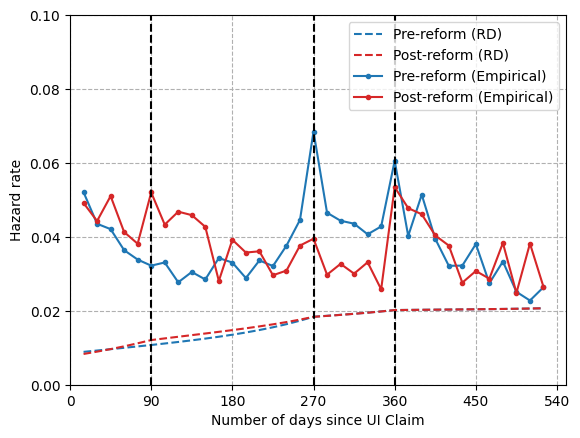

In [87]:
plt.plot(timevec, pre_st, label='Pre-reform (RD)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, post_st, label='Post-reform (RD)', linestyle='dashed', color='tab:red')
plt.plot(timevec, emp_pre, label='Pre-reform (Empirical)', marker='.', color='tab:blue')
plt.plot(timevec, emp_post, label='Post-reform (Empirical)', marker='.', color='tab:red')

plt.xlabel('Number of days since UI Claim')
plt.xticks(np.arange(0, 541, 90))
plt.xlim(0, 550) # set x-axis limits to first and last element in timevec


plt.ylim(0, 0.10)
plt.grid(True, linestyle='--')
plt.ylabel('Hazard rate')
#plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[(T1)*15, (T2)*15, (T3)*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed')
plt.legend()
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/Prediction HR_st.png', bbox_inches='tight')

plt.show()

In [88]:
params_st_full = pd.DataFrame(
    data={"value":params_st},
    index=["delta", "gamma", "eta", "k", "lmbda", "N"]
    )

In [89]:
smm_object = model.smm(params_st_full.copy(), target, W, institutions_pre, institutions_post, abar, weights, htm)

In [90]:
params_est_st = pd.DataFrame(
    data={"value":params_st[:5],
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01],
    "upper_bound" : [0.95, 2, 15, 2000, 15]},
    index=["delta", "gamma", "eta", "k", "lmbda"],
    )

In [91]:
res_st = om.minimize(criterion=smm_object.sse, params=params_est_st, algorithm='scipy_lbfgsb', )
print(f'Estimated parameters (L-BFGS-B): {res_st.params["value"].values}')
print(f'SMM SSE for estimated (L-BFGS-B): {res_st.criterion}')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:311: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/ho

KeyboardInterrupt: 

In [ ]:
est_params_st = params_st.copy()
est_params_st[:5] = res_st.params["value"].values


In [ ]:
moments_st_est = model.simulate_moments(est_params_st, institutions_pre, institutions_post, abar, weights, htm)
timevec = np.arange((len(moments_st))/2)*15 +15 # timevector for plotting graphs 
pre_est_st, post_est_st = split_half(moments_st)

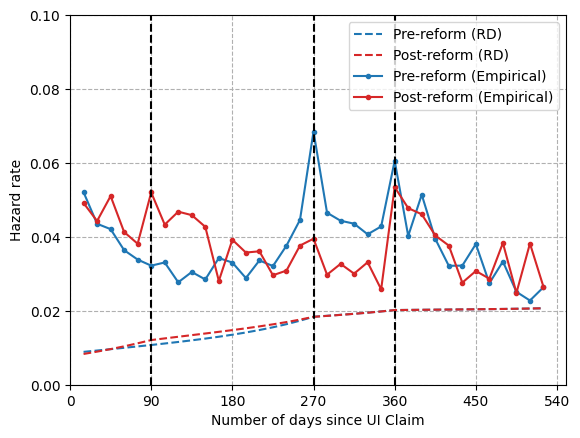

In [ ]:
plt.plot(timevec, pre_est_st, label='Pre-reform (RD)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, post_est_st, label='Post-reform (RD)', linestyle='dashed', color='tab:red')
plt.plot(timevec, emp_pre, label='Pre-reform (Empirical)', marker='.', color='tab:blue')
plt.plot(timevec, emp_post, label='Post-reform (Empirical)', marker='.', color='tab:red')

plt.xlabel('Number of days since UI Claim')
plt.xticks(np.arange(0, 541, 90))
plt.xlim(0, 550) # set x-axis limits to first and last element in timevec


plt.ylim(0, 0.10)
plt.grid(True, linestyle='--')
plt.ylabel('Hazard rate')
#plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[(T1)*15, (T2)*15, (T3)*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed')
plt.legend()
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/Prediction HR_st.png', bbox_inches='tight')

plt.show()

### 2 type model

In [ ]:
moments_2type = model.simulate_moments(params_twotype, institutions_pre, institutions_post, abar, weights, htm)
timevec = np.arange((len(moments_2type))/2)*15 +15 # timevector for plotting graphs 

# Create target (empirical moments) and covariance matrix
target, cov = model.matchingMoments()

# Create weighting function
W = np.linalg.inv(cov)

# Create SSE, distance measure
SSE = model.sse(params_twotype, target, W, institutions_pre, institutions_post, abar, weights, htm)
print(f'SSE (Goodness of Fit): {SSE}')

SSE (Goodness of Fit): 642.5110812146573


In [ ]:
pre_2type, post_2type = split_half(moments_2type)

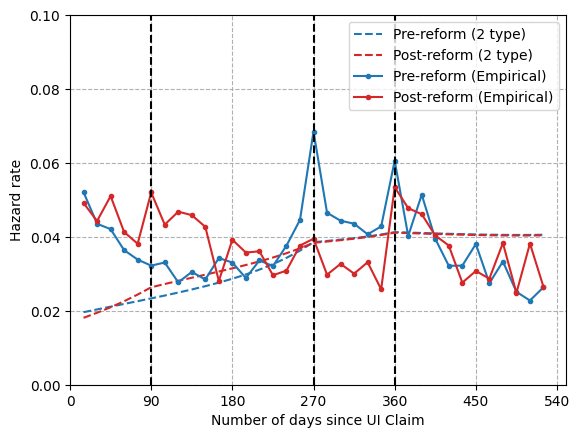

In [ ]:
plt.plot(timevec, pre_2type, label='Pre-reform (2 type)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, post_2type, label='Post-reform (2 type)', linestyle='dashed', color='tab:red')
plt.plot(timevec, emp_pre, label='Pre-reform (Empirical)', marker='.', color='tab:blue')
plt.plot(timevec, emp_post, label='Post-reform (Empirical)', marker='.', color='tab:red')

plt.xlabel('Number of days since UI Claim')
plt.xticks(np.arange(0, 541, 90))
plt.xlim(0, 550) # set x-axis limits to first and last element in timevec


plt.ylim(0, 0.10)
plt.grid(True, linestyle='--')
plt.ylabel('Hazard rate')
#plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[(T1)*15, (T2)*15, (T3)*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed')
plt.legend()
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/Prediction HR_st.png', bbox_inches='tight')

plt.show()

In [ ]:
params_2type_full = pd.DataFrame(
    data={"value":params_twotype},
    index=["delta", "gamma", "eta", "1", "lmbda", "N", "k2", "q1"]
    )

In [ ]:
smm_object = model.smm(params_2type_full.copy(), target, W, institutions_pre, institutions_post, abar, weights, htm)

In [ ]:
params_est_2type = pd.DataFrame(
    data={"value":np.delete(params_twotype,5),
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01, 0.01, 0],
    "upper_bound" : [0.95, 2, 15, 2000, 15, 2000, 1]},
    index=["delta", "gamma", "eta", "k1", "lmbda", "k2", "q1"],
    )

In [ ]:
res_2type = om.minimize(criterion=smm_object.sse, params=params_est_2type, algorithm='scipy_lbfgsb', )
print(f'Estimated parameters (L-BFGS-B): {res_2type.params["value"].values}')
print(f'SMM SSE for estimated (L-BFGS-B): {res_2type.criterion}')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:311: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/ho

KeyboardInterrupt: 

### 3 type model

In [ ]:
moments_3type = model.simulate_moments(params_multi, institutions_pre, institutions_post, abar, weights, htm)
timevec = np.arange((len(moments_3type))/2)*15 +15 # timevector for plotting graphs 

# Create target (empirical moments) and covariance matrix
target, cov = model.matchingMoments()

# Create weighting function
W = np.linalg.inv(cov)

# Create SSE, distance measure
SSE = model.sse(params_multi, target, W, institutions_pre, institutions_post, abar, weights, htm)
print(f'SSE (Goodness of Fit): {SSE}')

SSE (Goodness of Fit): 356.45125231042795


In [ ]:
pre_3type, post_3type = split_half(moments_3type)

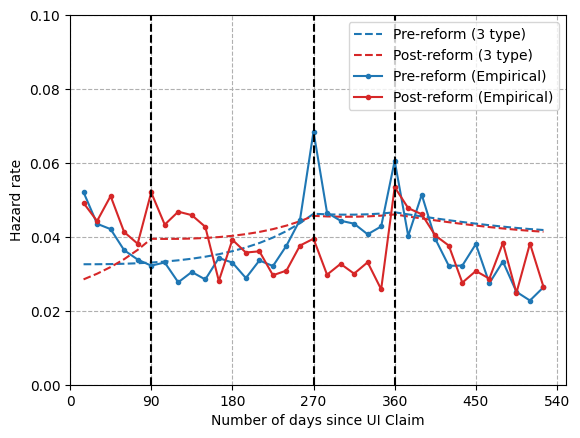

In [ ]:
plt.plot(timevec, pre_3type, label='Pre-reform (3 type)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, post_3type, label='Post-reform (3 type)', linestyle='dashed', color='tab:red')
plt.plot(timevec, emp_pre, label='Pre-reform (Empirical)', marker='.', color='tab:blue')
plt.plot(timevec, emp_post, label='Post-reform (Empirical)', marker='.', color='tab:red')

plt.xlabel('Number of days since UI Claim')
plt.xticks(np.arange(0, 541, 90))
plt.xlim(0, 550) # set x-axis limits to first and last element in timevec


plt.ylim(0, 0.10)
plt.grid(True, linestyle='--')
plt.ylabel('Hazard rate')
#plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[(T1)*15, (T2)*15, (T3)*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed')
plt.legend()
plt.savefig('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Figurer/Prediction HR_st.png', bbox_inches='tight')

plt.show()

In [ ]:
params_3type_full = pd.DataFrame(
    data={"value":params_multi},
    index=["delta", "gamma", "eta", "1", "lmbda", "N", "k2", "k3", "q1", "q2"]
    )

In [ ]:
smm_object = model.smm(params_3type_full.copy(), target, W, institutions_pre, institutions_post, abar, weights, htm)

In [ ]:
params_est_3type = pd.DataFrame(
    data={"value":np.delete(params_multi,5),
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01, 0.01, 0.01,0, 0],
    "upper_bound" : [0.95, 2, 15, 2000, 15, 2000, 2000, 1,1]},
    index=["delta", "gamma", "eta", "k1", "lmbda", "k2", "k3", "q1", "q2"],
    )

In [ ]:
res_3type = om.minimize(criterion=smm_object.sse, params=params_est_3type, algorithm='scipy_lbfgsb', )
print(f'Estimated parameters (L-BFGS-B): {res_3type.params["value"].values}')
print(f'SMM SSE for estimated (L-BFGS-B): {res_3type.criterion}')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


UserFunctionRuntimeError: An error occurred when evaluating a numerical derivative during optimization.

# Estimate Reference Dependent Model

## Simulate Moments, obtain empirical/observed moments, weigting matrix (covariance) and calculate sum of squared errors (distance measure)

In [ ]:
moments_rd = model.simulate_moments(params_rd, institutions_pre, institutions_post, abar, weights, htm)
timevec = np.arange((len(moments_rd))/2)*15 +15 # timevector for plotting graphs 

# Create SSE, distance measure
SSE = model.sse(params_rd, target, W, institutions_pre, institutions_post, abar, weights, htm)
print(f'SSE (Goodness of Fit): {SSE}')

SSE (Goodness of Fit): 120.74750301158201


In [ ]:
pre_rd, post_rd = split_half(moments_rd)

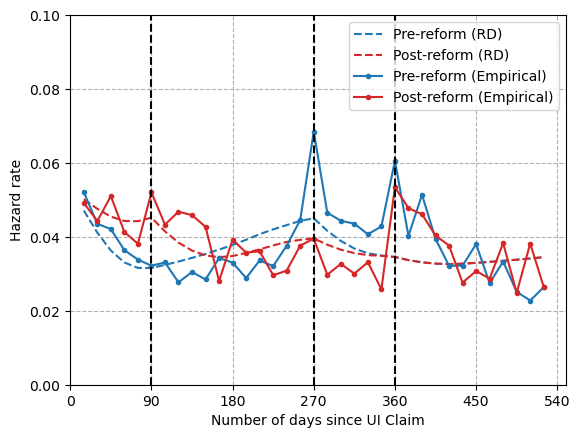

In [ ]:
plt.plot(timevec, pre_rd, label='Pre-reform (RD)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, post_rd, label='Post-reform (RD)', linestyle='dashed', color='tab:red')
plt.plot(timevec, emp_pre, label='Pre-reform (Empirical)', marker='.', color='tab:blue')
plt.plot(timevec, emp_post, label='Post-reform (Empirical)', marker='.', color='tab:red')

plt.xlabel('Number of days since UI Claim')
plt.xticks(np.arange(0, 541, 90))
plt.xlim(0, 550) # set x-axis limits to first and last element in timevec


plt.ylim(0, 0.10)
plt.grid(True, linestyle='--')
plt.ylabel('Hazard rate')
#plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[(T1)*15, (T2)*15, (T3)*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed')
plt.legend()

plt.savefig('/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Figurer/Prediction HR.pdf', bbox_inches='tight')

plt.show()

### Define full set of parameters in order to estimate model

In [12]:
params_rd_full = pd.DataFrame(
    data={"value":params_rd},
    index=["delta", "gamma", "eta", "k", "lmbda", "N"]
    )

params_est_rd = pd.DataFrame(
    data={"value":params_rd[:5],
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01],
    "upper_bound" : [0.95, 2, 15, 2000, 15]},
    index=["delta", "gamma", "eta", "k", "lmbda"],
    )

## Estimate with Simulated Method of Moments (RD Model & Hand To Mouth)
Call the Simulated Method of Moments object (SMM Class)
In this class we obtain the Distance/SSE Criterion which we minimize over. Allows us to update paramters we want to estimate, while holding all other variables fixed.

With params_rd we define the parameters we want to estimate with the reference dependent model, along with defining upper and lower bounds for each parameter

In [13]:
smm_object = model.smm(params_rd_full.copy(), target, W, institutions_pre, institutions_post, abar, weights, htm)

In [14]:
params_est_rd = pd.DataFrame(
    data={"value":params_rd[:5],
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01],
    "upper_bound" : [0.95, 2, 15, 2000, 15]},
    index=["delta", "gamma", "eta", "k", "lmbda"],
    )

In [15]:
params_est_std = pd.DataFrame(
    data={"value":params_rd[:5],
    "lower_bound" : [0.01, 0.0, 0.0, 1e-5, 0.01],
    "upper_bound" : [0.95, 0.0, 0.0, 2000, 15]},
    index=["delta", "gamma", "eta", "k", "lmbda"],
    )

Print Sum of Squared Errors at initial values

In [16]:
print(f'SMM SSE for params_rd: {smm_object.sse(params_rd)}')

SMM SSE for params_rd: 707.9312764809315


### Estimate params_rd by minimize the objective function (Algorithms L-BFGS-B and LS-TRF) 

In [17]:
res_lbfgsb = om.minimize(criterion=smm_object.criterion, params=params_est_rd, algorithm='scipy_lbfgsb', )
print(f'Estimated parameters (L-BFGS-B): {res_lbfgsb.params["value"].values}')
print(f'SMM SSE for estimated (L-BFGS-B): {res_lbfgsb.criterion}')

/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:333: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html
  warnings.warn(msg, FutureWarning)


Estimated parameters (L-BFGS-B): [  0.89217042   0.86301388   1.65159136 358.72612023   5.37024574]
SMM SSE for estimated (L-BFGS-B): 140.11151902140597


/opt/anaconda3/lib/python3.12/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning: The criterion attribute is deprecated. Use the fun attribute instead.
  warnings.warn(msg, FutureWarning)


### Plot criterion value at each iteration and number of criterion evaluations before reaching a solution

In [18]:
fig = om.criterion_plot(res_lbfgsb)
fig

### LS_TRF estimation

In [19]:
res_ls = om.minimize(criterion=smm_object.criterion, params=params_est_rd, algorithm='scipy_ls_trf', )
print(f'Estimated parameters (LS_TRF): {res_ls.params["value"].values}')
print(f'SMM SSE for estimated (LS_TRF): {res_ls.criterion}')

/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:53: FutureWarning:

To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.

/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:333: FutureWarning:

Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html



Estimated parameters (LS_TRF): [9.49970911e-01 1.17590515e+00 1.73359345e+00 1.99955420e+03
 8.63481452e+00]
SMM SSE for estimated (LS_TRF): 120.747503011582


/opt/anaconda3/lib/python3.12/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning:

The criterion attribute is deprecated. Use the fun attribute instead.



In [20]:
fig = om.criterion_plot(res_ls)
fig

## Plot estimated parameters for different minimizing algorithms
First we insert the estimated params on our original params array
Then we plot them against observed moments
Then we simulate the model with the estimated moments
Finally p

In [21]:
#insert 5 estimated params on first 5 columns of original params array
params_lbfgsb = params_rd
params_lbfgsb[:5] = res_lbfgsb.params["value"]

#insert params_rd on first 5 columns of params
params_lstfr = params_rd
params_lstfr[:5] = res_ls.params['value']



In [22]:
#simulate moments for each set of estimated parameters
# Then split the moments into pre- and post-reform moments for each set of estimated parameters
moments_lbfgsb = model.simulate_moments(params_lbfgsb, institutions_pre, institutions_post, abar, weights, htm)
opt_lbfgsb_pre, opt_lbfgsb_post = split_half(moments_lbfgsb)
moments_lstfr = model.simulate_moments(params_lstfr, institutions_pre, institutions_post, abar, weights, htm)
opt_lstfr_pre, opt_lstfr_post = split_half(moments_lstfr)

emp_pre, emp_post = split_half(target)


### Plot for the L-BGSB-B estimator

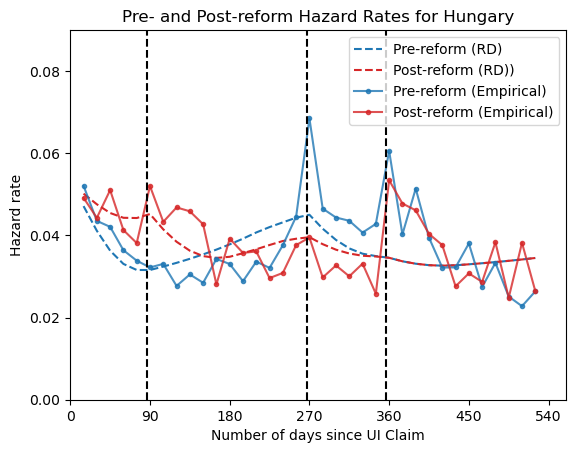

In [23]:
plt.plot(timevec, opt_lbfgsb_pre, label='Pre-reform (RD)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, opt_lbfgsb_post, label='Post-reform (RD))', linestyle='dashed', color='tab:red')
timevec2 = timevec + 15
plt.plot(timevec, emp_pre, label='Pre-reform (Empirical)', marker='.', color='tab:blue', alpha=0.8)
plt.plot(timevec, emp_post, label='Post-reform (Empirical)', marker='.', color='tab:red', alpha=0.8)

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.xticks(np.arange(0, 541, 90))
plt.ylabel('Hazard rate')
plt.ylim(0, 0.09) # set x-axis limits to first and last element in timevec
plt.yticks(np.arange(0, 0.09, 0.02))
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[T1*15-3, T2*15-3, T3*15-3], ymin=0, ymax=0.15, colors='black', linestyles='dashed')
plt.legend()
plt.show()

#### Goodness of Fit (SSE), L-BGSB-B estimator

In [24]:
res_ls.params
res_lbfgsb.params

,value,lower_bound,upper_bound
delta,0.892170,0.01000,0.95
gamma,0.863014,0.01000,2.00
eta,1.651591,0.01000,15.00
k,358.726120,0.00001,2000.00
lmbda,5.370246,0.01000,15.00


### Plot for the L-STFR estimator

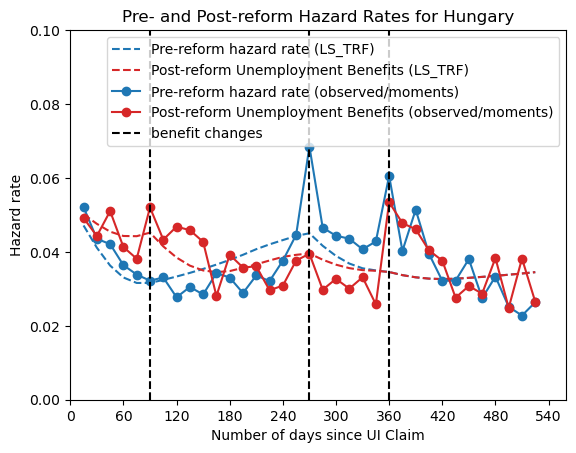

In [25]:
plt.plot(timevec, opt_lstfr_pre, label='Pre-reform hazard rate (LS_TRF)', linestyle='dashed', color='tab:blue')
plt.plot(timevec, opt_lstfr_post, label='Post-reform Unemployment Benefits (LS_TRF)', linestyle='dashed', color='tab:red')
plt.plot(timevec, emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='tab:blue')
plt.plot(timevec, emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='tab:red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.ylim(0, 0.1) # set x-axis limits to first and last element in timevec
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

## Estimate with Simulated Method of Moments (RD Model & Heterogenous Assets)
Call the Simulated Method of Moments object (SMM Class)
In this class we obtain the Distance/SSE Criterion which we minimize over. Allows us to update paramters we want to estimate, while holding all other variables fixed.

With params_rd we define the parameters we want to estimate with the reference dependent model, along with defining upper and lower bounds for each parameter

## Estimate with Simulated Method of Moments (Standard Model & Hand To Mouth)
Call the Simulated Method of Moments object (SMM Class)
In this class we obtain the Distance/SSE Criterion which we minimize over. Allows us to update paramters we want to estimate, while holding all other variables fixed.

With params_rd we define the parameters we want to estimate with the reference dependent model, along with defining upper and lower bounds for each parameter

## Estimate with Simulated Method of Moments (Standard Model & Heterogenous Assets)
Call the Simulated Method of Moments object (SMM Class)
In this class we obtain the Distance/SSE Criterion which we minimize over. Allows us to update paramters we want to estimate, while holding all other variables fixed.

With params_rd we define the parameters we want to estimate with the reference dependent model, along with defining upper and lower bounds for each parameter